# Laboratorio 8: Análisis de Datos

<div style="padding: 30px; background-color: #ffffff; border-radius: 15px; border: 1px solid #e1e4e8; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin-bottom: 30px; text-align: center;">
    <h1 style="color: #2c3e50; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin-bottom: 10px;">Inmersión Profunda en Pandas: Análisis de Datos Profesional</h1>
    <p style="font-size: 1.2em; color: #7f8c8d; font-style: italic; margin-bottom: 20px;">Dominando DataFrames, Manipulaciones y Visualizaciones</p>
    <div style="width: 100px; height: 4px; background-color: #3498db; margin: 0 auto 20px;"></div>
    <p style="color: #34495e; font-weight: 500;">Tutorial Técnico y Reporte</p>
</div>

---

### 📌 Tabla de Contenidos
1. [Configuración del Entorno](#setup)
2. [Adquisición y Limpieza de Datos](#cleaning)
3. [Análisis Exploratorio de Datos (EDA)](#eda)
4. [Manipulaciones Avanzadas](#manipulation)
5. [Agrupaciones y Agregaciones](#aggregation)
6. [Integración de Datos (Joins y Merges)](#merges)
7. [Exportación de Datos](#export)
8. [Visualizaciones e Insights](#visualization)
9. [Aplicaciones Prácticas](#practice)

<a id='setup'></a>
## 🛠️ 1. Configuración del Entorno
Antes de comenzar con el análisis, nos aseguramos de importar todas las librerías necesarias y configurarlas para la visualización integrada.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Configurar gráficos para que se muestren dentro del notebook
%matplotlib inline

# Verificar la versión de la librería
print(f"Versión de Pandas: {pd.__version__}")

Versión de Pandas: 3.0.0


<hr style="border: 0.5px solid #eee;">

<a id='cleaning'></a>
## 🧼 2. Adquisición y Limpieza de Datos
En esta sección, cargamos el conjunto de datos crudos y realizamos transformaciones iniciales, como el renombrado de columnas para una mejor legibilidad e indexación.

In [2]:
# Carga de datos
peru_df = pd.read_csv('peru_df.csv')

# Renombrado profesional de columnas
peru_df.rename(columns={
    'cap': 'Capital',
    'pob': 'Población (millones)',
    'departamento': 'Departamento',
    'area_km2': 'Superficie (km²)',
    'provincias': 'Provincias',
    'region': 'Región',
    'altitud_m': 'Altitud (msnm)',
    'pib_per_capita': 'PIB per cápita'
}, inplace=True)

# Normalización de datos de población (asumiendo que están en miles)
peru_df['Población (millones)'] = peru_df['Población (millones)'] / 1000

# Establecer un índice significativo
peru_df.set_index('Departamento', inplace=True)

peru_df.head()

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita
Departamento,,,,,,,
Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200
Áncash,Huaraz,1.199,35825,20,Sierra,3052,7600
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200
Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800
Ayacucho,Ayacucho,0.670,43890,11,Sierra,2761,4500


<hr style="border: 0.5px solid #eee;">

<a id='eda'></a>
## 📊 3. Análisis Exploratorio de Datos (EDA)
Comprender la distribución y las características de nuestros datos utilizando resúmenes estadísticos y muestreo aleatorio.

In [3]:
# Vista general de metadatos
peru_df.info()

# Muestra aleatoria para inspección
peru_df.sample(5)

<class 'pandas.DataFrame'>
Index: 25 entries, Amazonas to Ucayali
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Capital               25 non-null     str    
 1   Población (millones)  25 non-null     float64
 2   Superficie (km²)      25 non-null     int64  
 3   Provincias            25 non-null     int64  
 4   Región                25 non-null     str    
 5   Altitud (msnm)        25 non-null     int64  
 6   PIB per cápita        25 non-null     int64  
dtypes: float64(1), int64(4), str(2)
memory usage: 1.6+ KB


,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita
Departamento,,,,,,,
Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200
Cusco,Cusco,1.390,71873,13,Sierra,3399,7200
Ucayali,Pucallpa,0.627,102410,4,Selva,154,4800
Pasco,Cerro de Pasco,0.267,25319,3,Sierra,4330,5800
Lambayeque,Chiclayo,1.351,14231,3,Costa,27,6200


In [4]:
# Estadísticas descriptivas
peru_df.describe()

,Población (millones),Superficie (km²),Provincias,Altitud (msnm),PIB per cápita
count,25.00000,25.000000,25.000000,25.000000,25.000000
mean,1.34896,51438.360000,7.840000,1596.800000,6700.000000
std,2.11797,70655.265313,4.469154,1488.992445,2542.636427
min,0.19100,146.000000,1.000000,5.000000,3800.000000
25%,0.42800,21328.000000,4.000000,154.000000,4800.000000
50%,1.04100,35733.000000,8.000000,1410.000000,6200.000000
75%,1.37800,51842.000000,11.000000,2761.000000,7600.000000
max,11.14800,368852.000000,20.000000,4330.000000,14200.000000


<hr style="border: 0.5px solid #eee;">

<a id='manipulation'></a>
## ⚙️ 4. Manipulaciones Avanzadas
Esta sección demuestra selecciones complejas, ingeniería de características personalizadas usando `.apply()` y filtrado condicional.

### Selección de Columnas e Indexación
Recuperación de dimensiones específicas de nuestro conjunto de datos para un análisis enfocado.

In [5]:
# Selección de atributos específicos
subset = peru_df[['Capital', 'Altitud (msnm)', 'Región']]
subset.head()

,Capital,Altitud (msnm),Región
Departamento,,,
Amazonas,Chachapoyas,2334,Selva
Áncash,Huaraz,3052,Sierra
Apurímac,Abancay,2378,Sierra
Arequipa,Arequipa,2335,Costa
Ayacucho,Ayacucho,2761,Sierra


### Ingeniería de Características Personalizada
Categorización de departamentos basada en su desempeño económico utilizando el método `.apply()`.

In [6]:
def segmentar_pib(valor):
    """Clasifica el desempeño económico basado en el PIB per cápita."""
    if valor > 9000:
        return 'Alto'
    elif 5000 <= valor <= 9000:
        return 'Medio'
    else:
        return 'Bajo'

peru_df['Nivel Económico'] = peru_df['PIB per cápita'].apply(segmentar_pib)
peru_df[['PIB per cápita', 'Nivel Económico']].head()

,PIB per cápita,Nivel Económico
Departamento,,
Amazonas,4200,Bajo
Áncash,7600,Medio
Apurímac,5200,Medio
Arequipa,8800,Medio
Ayacucho,4500,Bajo


### Filtrado de Precisión
Extracción de observaciones específicas utilizando selección basada en etiquetas (`loc`) y basada en posición (`iloc`).

In [7]:
# Selección por etiqueta
peru_df.loc[['Cusco', 'Arequipa', 'Lima'], ['Población (millones)', 'Región']]

,Población (millones),Región
Departamento,,
Cusco,1.390,Sierra
Arequipa,1.580,Costa
Lima,11.148,Costa


In [8]:
# Selección por posición
peru_df.iloc[[7, 3, 14], [1, 4]]

,Población (millones),Región
Departamento,,
Cusco,1.390,Sierra
Arequipa,1.580,Costa
Lima,11.148,Costa


### Indexación Booleana
Filtrado del conjunto de datos para aislar departamentos con baja población o aquellos ubicados en la región Sierra.

In [9]:
# Filtro: Población < 0.5 Millones
peru_df[peru_df['Población (millones)'] < 0.5]

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico
Departamento,,,,,,,,
Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200,Bajo
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200,Medio
Huancavelica,Huancavelica,0.343,22131,7,Sierra,3676,3800,Bajo
Madre de Dios,Puerto Maldonado,0.191,85300,3,Selva,186,6800,Medio
Moquegua,Moquegua,0.199,15733,3,Costa,1410,11000,Alto
Pasco,Cerro de Pasco,0.267,25319,3,Sierra,4330,5800,Medio
Tacna,Tacna,0.390,16075,4,Costa,562,9000,Medio
Tumbes,Tumbes,0.263,4669,3,Costa,7,5300,Medio


In [10]:
# Filtro: Región Sierra
peru_df[peru_df['Región'] == 'Sierra']

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico
Departamento,,,,,,,,
Áncash,Huaraz,1.199,35825,20,Sierra,3052,7600,Medio
Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200,Medio
Ayacucho,Ayacucho,0.670,43890,11,Sierra,2761,4500,Bajo
Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800,Bajo
Cusco,Cusco,1.390,71873,13,Sierra,3399,7200,Medio
Huancavelica,Huancavelica,0.343,22131,7,Sierra,3676,3800,Bajo
Huánuco,Huanuco,0.751,36887,11,Sierra,1890,4300,Bajo
Junín,Huancayo,1.378,44410,9,Sierra,3250,6500,Medio
Pasco,Cerro de Pasco,0.267,25319,3,Sierra,4330,5800,Medio


<hr style="border: 0.5px solid #eee;">

<a id='aggregation'></a>
## 📈 5. Agrupaciones y Agregaciones
Resumen de datos a nivel regional para revelar patrones macroeconómicos.

In [11]:
# Agregación de población por región y nivel económico
resumen = peru_df.groupby(by=['Región', 'Nivel Económico'])['Población (millones)'].sum()
resumen

Región  Nivel Económico
Costa   Alto               13.579
        Medio               7.815
Selva   Bajo                1.057
        Medio               2.178
Sierra  Bajo                4.433
        Medio               4.662
Name: Población (millones), dtype: float64

### Ordenamiento y Creación de Atributos
Cálculo de la densidad poblacional y ordenamiento de los resultados para identificar valores atípicos clave.

In [12]:
# Ordenar por población
peru_df.sort_values(by='Población (millones)', ascending=False).head()

,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico
Departamento,,,,,,,,
Lima,Lima,11.148,34801,10,Costa,154,14200,Alto
Piura,Piura,2.127,35733,8,Costa,29,6200,Medio
La Libertad,Trujillo,2.104,25699,12,Costa,34,7000,Medio
Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800,Medio
Cajamarca,Cajamarca,1.451,33317,13,Sierra,2750,4800,Bajo


In [13]:
# Cálculo de la Densidad Poblacional
peru_df['Densidad (hab/km²)'] = (peru_df['Población (millones)'] * 1_000_000) / peru_df['Superficie (km²)']
peru_df[['Población (millones)', 'Superficie (km²)', 'Densidad (hab/km²)']].head()

,Población (millones),Superficie (km²),Densidad (hab/km²)
Departamento,,,
Amazonas,0.430,39249,10.955693
Áncash,1.199,35825,33.468248
Apurímac,0.428,20895,20.483369
Arequipa,1.580,63345,24.942774
Ayacucho,0.670,43890,15.265436


### Multi-Agregación
Aplicación de múltiples funciones estadísticas simultáneamente para explorar los límites de los datos.

In [14]:
# Estadísticas en lote
peru_df[["Población (millones)", "PIB per cápita"]].agg(["min", "max", "mean"])

,Población (millones),PIB per cápita
min,0.19100,3800.0
max,11.14800,14200.0
mean,1.34896,6700.0


<hr style="border: 0.5px solid #eee;">

<a id='export'></a>
## 💾 6. Exportación de Datos
Garantizar la interoperabilidad guardando los datos procesados en varios formatos profesionales.

In [15]:
# Exportación a múltiples formatos
peru_df.to_excel("peru_df_final.xlsx", index=True)
peru_df.to_csv("peru_df_final.csv", index=True, encoding='utf-8-sig')
peru_df.to_json("peru_df_final.json", orient="records", indent=4)
peru_df.to_html("peru_df_final.html")

print("¡Todos los archivos se exportaron exitosamente!")

¡Todos los archivos se exportaron exitosamente!


<hr style="border: 0.5px solid #eee;">

<a id='merges'></a>
## 🔗 7. Integración de Datos (Joins y Merges)
Combinación de nuestro conjunto de datos primario con datos de proyectos auxiliares utilizando diferentes estrategias de unión.

In [16]:
# Conjunto de datos de proyectos auxiliares
data_proyectos = {
    'Departamento': ['Arequipa', 'Lima', 'Cusco', 'Piura', 'Loreto', 'Extranjero'],
    'Inversion_Millones': [1500, 4200, 850, 600, 300, 5000],
    'Tipo_Proyecto': ['Minería', 'Transporte', 'Energía', 'Agricultura', 'Ambiental', 'Comercio'],
    'Estado': ['Ejecución', 'Planificación', 'Ejecución', 'Finalizado', 'Suspendido', 'Nuevo']
}
proyectos_df = pd.DataFrame(data_proyectos)

### Comparación de Tipos de Join
Visualización de cómo las diferentes estrategias de unión afectan el resultado.

In [17]:
# Inner Join: Solo registros comunes
inner_df = pd.merge(peru_df.reset_index(), proyectos_df, on='Departamento', how='inner')
inner_df.head()

,Departamento,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²),Inversion_Millones,Tipo_Proyecto,Estado
0,Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800,Medio,24.942774,1500,Minería,Ejecución
1,Cusco,Cusco,1.390,71873,13,Sierra,3399,7200,Medio,19.339669,850,Energía,Ejecución
2,Lima,Lima,11.148,34801,10,Costa,154,14200,Alto,320.335623,4200,Transporte,Planificación
3,Loreto,Iquitos,1.052,368852,8,Selva,104,5400,Medio,2.852092,300,Ambiental,Suspendido
4,Piura,Piura,2.127,35733,8,Costa,29,6200,Medio,59.524809,600,Agricultura,Finalizado


In [18]:
# Left Join: Preservar todos los datos primarios
left_df = pd.merge(peru_df.reset_index(), proyectos_df, on='Departamento', how='left')
left_df.head()

,Departamento,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²),Inversion_Millones,Tipo_Proyecto,Estado
0,Amazonas,Chachapoyas,0.430,39249,7,Selva,2334,4200,Bajo,10.955693,NaN,NaN,NaN
1,Áncash,Huaraz,1.199,35825,20,Sierra,3052,7600,Medio,33.468248,NaN,NaN,NaN
2,Apurímac,Abancay,0.428,20895,7,Sierra,2378,5200,Medio,20.483369,NaN,NaN,NaN
3,Arequipa,Arequipa,1.580,63345,8,Costa,2335,8800,Medio,24.942774,1500.0,Minería,Ejecución
4,Ayacucho,Ayacucho,0.670,43890,11,Sierra,2761,4500,Bajo,15.265436,NaN,NaN,NaN


In [19]:
# Right Join: Enfocado en los datos de proyectos auxiliares
right_df = pd.merge(peru_df.reset_index(), proyectos_df, on='Departamento', how='right')
right_df.tail()

,Departamento,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²),Inversion_Millones,Tipo_Proyecto,Estado
1,Lima,Lima,11.148,34801.0,10.0,Costa,154.0,14200.0,Alto,320.335623,4200,Transporte,Planificación
2,Cusco,Cusco,1.390,71873.0,13.0,Sierra,3399.0,7200.0,Medio,19.339669,850,Energía,Ejecución
3,Piura,Piura,2.127,35733.0,8.0,Costa,29.0,6200.0,Medio,59.524809,600,Agricultura,Finalizado
4,Loreto,Iquitos,1.052,368852.0,8.0,Selva,104.0,5400.0,Medio,2.852092,300,Ambiental,Suspendido
5,Extranjero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000,Comercio,Nuevo


In [20]:
# Outer Join: Unión completa de ambos conjuntos de datos
outer_df = pd.merge(peru_df.reset_index(), proyectos_df, on='Departamento', how='outer')
outer_df.head()

,Departamento,Capital,Población (millones),Superficie (km²),Provincias,Región,Altitud (msnm),PIB per cápita,Nivel Económico,Densidad (hab/km²),Inversion_Millones,Tipo_Proyecto,Estado
0,Amazonas,Chachapoyas,0.430,39249.0,7.0,Selva,2334.0,4200.0,Bajo,10.955693,NaN,NaN,NaN
1,Apurímac,Abancay,0.428,20895.0,7.0,Sierra,2378.0,5200.0,Medio,20.483369,NaN,NaN,NaN
2,Arequipa,Arequipa,1.580,63345.0,8.0,Costa,2335.0,8800.0,Medio,24.942774,1500.0,Minería,Ejecución
3,Ayacucho,Ayacucho,0.670,43890.0,11.0,Sierra,2761.0,4500.0,Bajo,15.265436,NaN,NaN,NaN
4,Cajamarca,Cajamarca,1.451,33317.0,13.0,Sierra,2750.0,4800.0,Bajo,43.551340,NaN,NaN,NaN


### Concatenación Vertical y Horizontal
Unión de DataFrames a lo largo de un eje sin utilizar claves.

In [21]:
# Concatenación horizontal (Añadir columnas)
data_encargados = {
    'Responsable': ['Ing. García', 'Dra. López', 'Ing. Torres', 'Lic. Ruiz', 'Ing. Salas', 'Eco. Benites'],
    'Fecha_Inicio': ['2024-01', '2023-11', '2024-03', '2023-06', '2024-05', '2024-08']
}
encargados_df = pd.DataFrame(data_encargados)
proyectos_extendido = pd.concat([proyectos_df, encargados_df], axis=1)
proyectos_extendido

,Departamento,Inversion_Millones,Tipo_Proyecto,Estado,Responsable,Fecha_Inicio
0,Arequipa,1500,Minería,Ejecución,Ing. García,2024-01
1,Lima,4200,Transporte,Planificación,Dra. López,2023-11
2,Cusco,850,Energía,Ejecución,Ing. Torres,2024-03
3,Piura,600,Agricultura,Finalizado,Lic. Ruiz,2023-06
4,Loreto,300,Ambiental,Suspendido,Ing. Salas,2024-05
5,Extranjero,5000,Comercio,Nuevo,Eco. Benites,2024-08


In [22]:
# Concatenación vertical (Añadir filas)
data_nuevos = {'Departamento': ['Tacna', 'Puno'], 'Inversion_Millones': [450, 920]}
nuevos_df = pd.DataFrame(data_nuevos)
proyectos_final = pd.concat([proyectos_df, nuevos_df], axis=0).reset_index(drop=True)
proyectos_final

,Departamento,Inversion_Millones,Tipo_Proyecto,Estado
0,Arequipa,1500,Minería,Ejecución
1,Lima,4200,Transporte,Planificación
2,Cusco,850,Energía,Ejecución
3,Piura,600,Agricultura,Finalizado
4,Loreto,300,Ambiental,Suspendido
5,Extranjero,5000,Comercio,Nuevo
6,Tacna,450,NaN,NaN
7,Puno,920,NaN,NaN


<hr style="border: 0.5px solid #eee;">

<a id='visualization'></a>
## 🖼️ 8. Visualizaciones e Insights
Comunicación de tendencias de datos a través de visualizaciones potentes pero limpias.

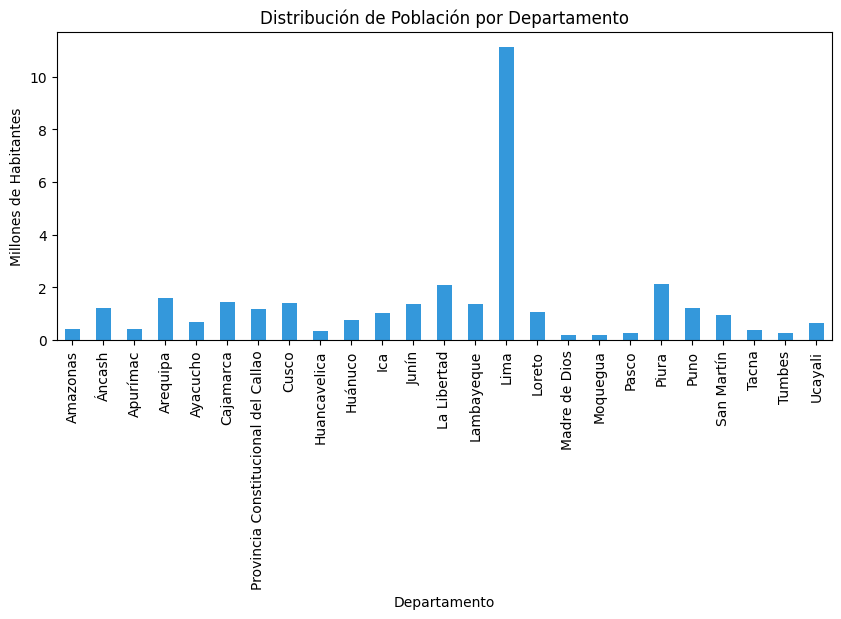

In [23]:
# 📊 Gráfico de Barras: Población por Departamento
peru_df['Población (millones)'].plot(kind='bar', figsize=(10, 4), color='#3498db')
plt.title('Distribución de Población por Departamento')
plt.ylabel('Millones de Habitantes')
plt.show()

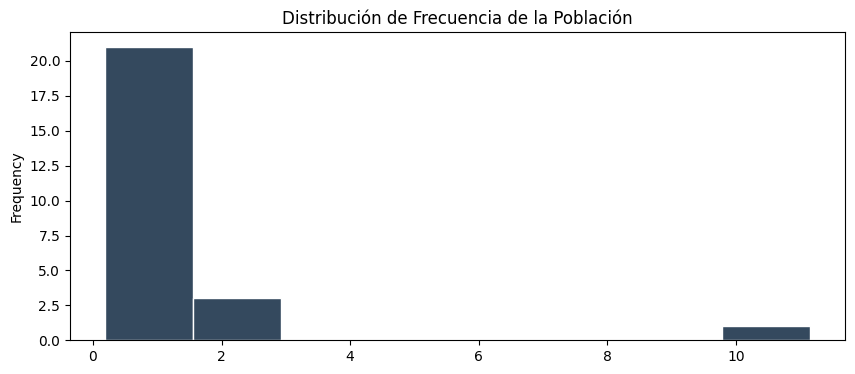

In [24]:
# 🗳️ Histograma: Frecuencia de Distribución
peru_df['Población (millones)'].plot(kind='hist', bins=8, figsize=(10, 4), color='#34495e', edgecolor='white')
plt.title('Distribución de Frecuencia de la Población')
plt.show()

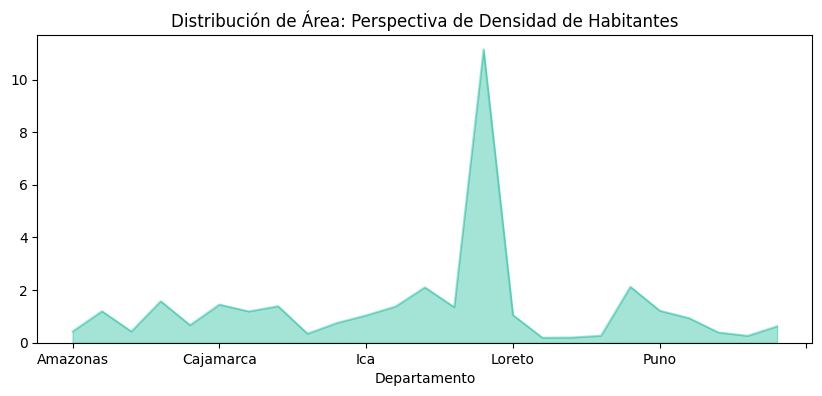

In [25]:
# 🎨 Gráfico de Área: Vista Acumulativa
peru_df['Población (millones)'].plot(kind='area', figsize=(10, 4), alpha=0.4, color='#1abc9c')
plt.title('Distribución de Área: Perspectiva de Densidad de Habitantes')
plt.show()

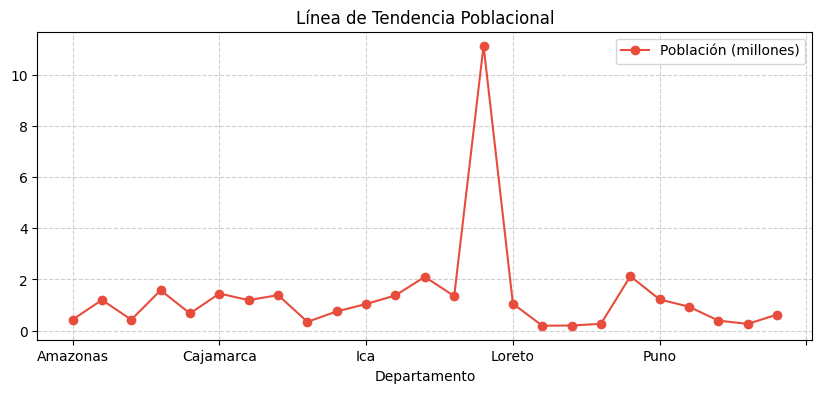

In [26]:
# 📈 Gráfico de Líneas: Tendencia Poblacional
peru_df[['Población (millones)']].plot(kind='line', figsize=(10, 4), marker='o', color='#e74c3c')
plt.title('Línea de Tendencia Poblacional')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

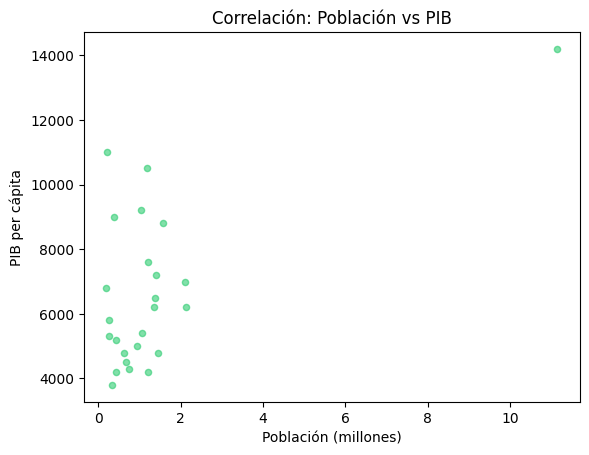

In [27]:
# 📉 Gráfico de Dispersión: Población vs PIB
peru_df.plot(kind='scatter', x='Población (millones)', y='PIB per cápita', color='#2ecc71', alpha=0.6)
plt.title('Correlación: Población vs PIB')
plt.show()

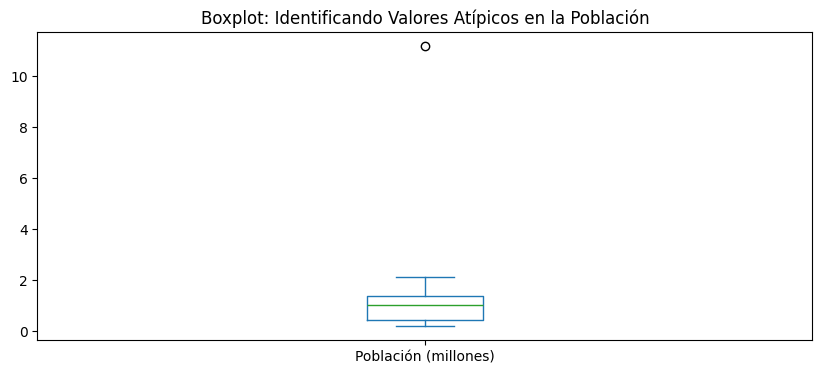

In [28]:
# 📦 Boxplot: Valores Atípicos Estadísticos
peru_df['Población (millones)'].plot(kind='box', figsize=(10, 4))
plt.title('Boxplot: Identificando Valores Atípicos en la Población')
plt.show()

<hr style="border: 0.5px solid #eee;">

<a id='practice'></a>
## 📝 9. Aplicaciones Prácticas
Evaluación de la competencia lógica a través de la generación de datos basada en geometría.

In [29]:
import numpy as np

# 1. Crear DataFrame base
df_geo = pd.DataFrame({'RADIO': range(1, 21)})

# 2. Calcular Área (pi * r^2)
df_geo['AREA'] = np.pi * (df_geo['RADIO']**2)

# 3. Calcular Volumen (4/3 * pi * r^3)
df_geo['VOLUMEN'] = (4/3) * np.pi * (df_geo['RADIO']**3)

df_geo.head()

,RADIO,AREA,VOLUMEN
0,1,3.141593,4.188790
1,2,12.566371,33.510322
2,3,28.274334,113.097336
3,4,50.265482,268.082573
4,5,78.539816,523.598776


<div style="padding: 20px; background-color: #f1f2f6; border-radius: 10px; text-align: center; margin-top: 30px;">
    <p style="color: #2f3542; font-weight: 600;">Fin del Reporte de Inmersión Profunda en Pandas</p>
    <p style="font-size: 0.9em; color: #57606f;">Generado con atención a la excelencia técnica.</p>
</div>